### 9. Denna uppgift består av flera steg enligt nedan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

## a) Läs in datasetet

In [2]:
data = pd.read_csv("../../data/data_01.csv")

In [3]:
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      199 non-null    float64
 1   x2      199 non-null    float64
 2   x3      199 non-null    float64
 3   x4      199 non-null    float64
 4   x5      199 non-null    float64
 5   target  199 non-null    float64
dtypes: float64(6)
memory usage: 9.5 KB


,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054
3,1.210186,1.685258,-0.394123,0.719024,-2.166585,165.930461
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473,43.250511


## b) Dela upp datasetet i X och y

In [4]:
X = data.drop(columns=["target"])
y = data["target"]

## c) Dela upp i tränings-, validerings- och testset

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15)

## d) Träna två regressionsmodeller på träningsdatan

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

In [7]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_train, y_train)
tree_reg_pred = tree_reg.predict(X_val)

## e) Utvärdera modellerna på valideringsdatan

In [8]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


validation_results = pd.DataFrame(
    {
        "Linear Regression": regression_metrics(y_val, lin_reg_pred),
        "Decision Tree": regression_metrics(y_val, tree_reg_pred),
    }
).T

validation_results

,MAE,RMSE
Linear Regression,2.715310,3.452875
Decision Tree,85.520977,100.032750


Text(0.5, 1.0, 'Decision Tree')

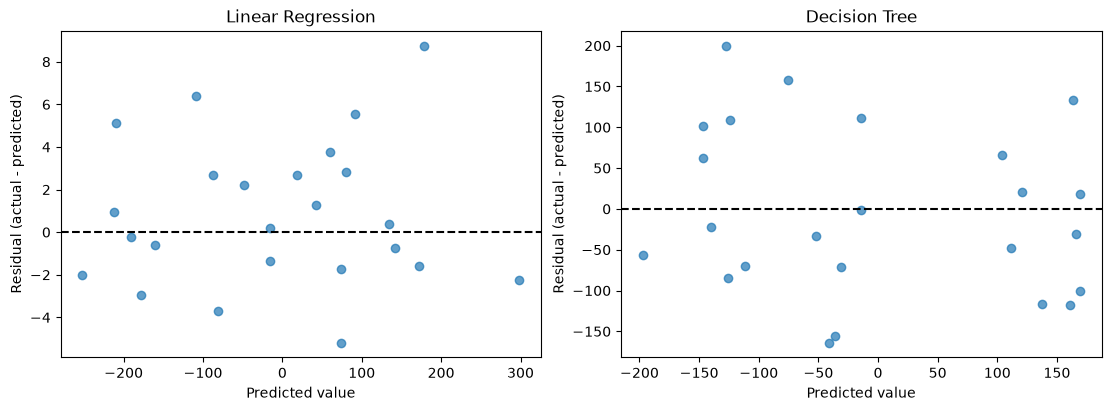

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

# Linear regression
lin_reg_residuals = y_val - lin_reg_pred

axs[0].scatter(lin_reg_pred, lin_reg_residuals, alpha=0.7)
axs[0].axhline(0, color="black", linestyle="--")
axs[0].set_xlabel("Predicted value")
axs[0].set_ylabel("Residual (actual - predicted)")
axs[0].set_title("Linear Regression")

# Decision tree
tree_reg_residuals = y_val - tree_reg_pred

axs[1].scatter(tree_reg_pred, tree_reg_residuals, alpha=0.7)
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_xlabel("Predicted value")
axs[1].set_ylabel("Residual (actual - predicted)")
axs[1].set_title("Decision Tree")

## f) Träna om den bäst presterande modellen på tränings- och valideringsdatan

In [10]:
lin_reg_final = LinearRegression().fit(X_train_full, y_train_full)

## g) Utvärdera modellen på testdatan

In [11]:
pred_test = lin_reg_final.predict(X_test)

test_results = pd.Series(regression_metrics(y_test, pred_test), name="Test set")
test_results

MAE     2.476574
RMSE    3.028455
Name: Test set, dtype: float64

## h) Träna om modellen på hela datasetet

In [12]:
final_model = LinearRegression()
final_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[77.24,87.85,71.77,28.45,31.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['x1','x2','x3','x4','x5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1269
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
